# Sex & Age Prediction

## Class Imbalance

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def load_data(age_path, sex_path, split_name):
    # Load age: skip first column (filename), name the second 'Age'
    age_df = pd.read_csv(age_path, sep=' ', header=None, usecols=[1], names=['Age'])
    
    # Load sex: skip first column, use columns 1 and 2 for one-hot encoding
    sex_df = pd.read_csv(sex_path, sep=' ', header=None, usecols=[1, 2])
    
    # Convert one-hot [1, 0] to 'Male' and [0, 1] to 'Female'
    # Using .idxmax(axis=1) picks the column index with the '1'
    sex_labels = sex_df.idxmax(axis=1).map({1: 'Male', 2: 'Female'})
    
    df = pd.DataFrame({'Age': age_df['Age'], 'Sex': sex_labels})
    df['Split'] = split_name
    return df

# Combine all sets
splits = [
    load_data('~/EVA-X/regression/datasets/data_splits/cxr14/age_labels_train.txt', 
              '~/EVA-X/classification/datasets/data_splits/cxr14/sex_labels_train.txt', 'Train'),
    load_data('~/EVA-X/regression/datasets/data_splits/cxr14/age_labels_test.txt', 
              '~/EVA-X/classification/datasets/data_splits/cxr14/sex_labels_test.txt', 'Test'),
    load_data('~/EVA-X/regression/datasets/data_splits/cxr14/age_labels_val.txt', 
              '~/EVA-X/classification/datasets/data_splits/cxr14/sex_labels_val.txt', 'Validation'),
]
full_df = pd.concat(splits, ignore_index=True)
filter_df = full_df[full_df['Age'] <= 100]
full_df

,Age,Sex,Split
0,58,Male,Train
1,58,Male,Train
2,58,Male,Train
3,81,Male,Train
4,82,Male,Train
...,...,...,...
112115,68,Female,Validation
112116,26,Female,Validation
112117,26,Female,Validation
112118,26,Female,Validation


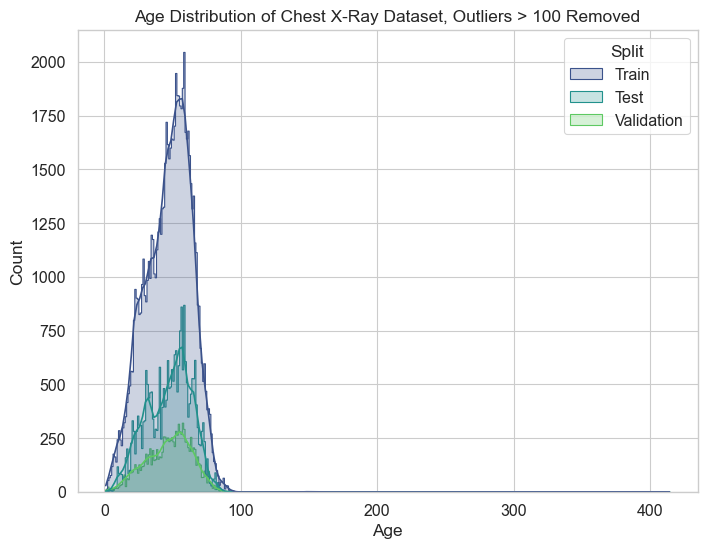

In [72]:
plt.figure(figsize=(8, 6))
sns.histplot(data=full_df, x='Age', hue='Split', kde=True, element="step", palette='viridis')
plt.title('Age Distribution of Chest X-Ray Dataset, Outliers > 100 Removed')
plt.show()

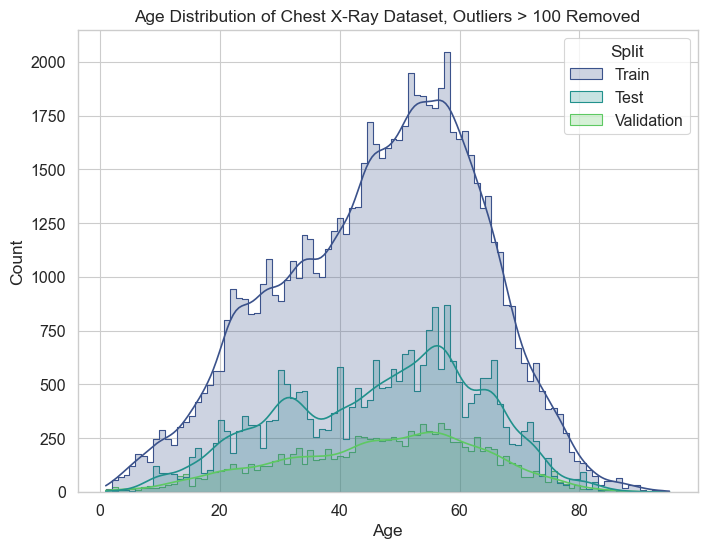

In [71]:
plt.figure(figsize=(8, 6))
sns.histplot(data=filter_df, x='Age', hue='Split', kde=True, element="step", palette='viridis')
plt.title('Age Distribution of Chest X-Ray Dataset, Outliers > 100 Removed')
plt.show()

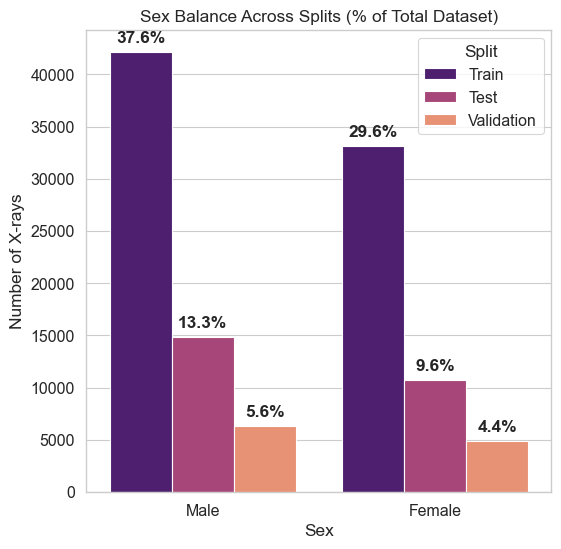

In [70]:
plt.figure(figsize=(6, 6))
ax = sns.countplot(data=full_df, x='Sex', hue='Split', palette='magma')

# Calculate the total number of samples for the percentage denominator
total = len(full_df)

for p in ax.patches:
    height = p.get_height()
    if height > 0: # Avoid labeling empty bars
        percentage = f'{100 * height / total:.1f}%'
        ax.annotate(percentage, 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 10), 
                    textcoords='offset points',
                    fontweight='bold')

plt.title('Sex Balance Across Splits (% of Total Dataset)')
plt.ylabel('Number of X-rays')
plt.show()

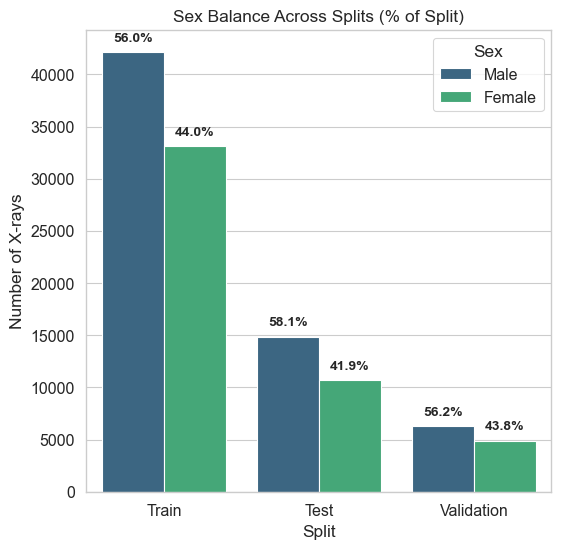

In [69]:
plt.figure(figsize=(6, 6))

ax = sns.countplot(data=full_df, x='Split', hue='Sex', palette='viridis')

# 1. Get the total counts for each split (the denominator)
split_counts = full_df.groupby('Split').size().to_dict()

# 2. Get the labels from the X-axis to match the index to the name
# e.g., {0: 'Train', 1: 'Test', 2: 'Eval'}
labels = [l.get_text() for l in ax.get_xticklabels()]

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        # p.get_x() gives the left edge. Adding half-width gives the center.
        # Rounding/Casting to int gives us the index (0, 1, or 2)
        idx = int(round(p.get_x() + p.get_width() / 2.))
        current_split = labels[idx]
        
        # Calculate percentage relative to THAT split's total
        total_for_this_split = split_counts[current_split]
        percentage = f'{100 * height / total_for_this_split:.1f}%'
        
        ax.annotate(percentage, 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 10), 
                    textcoords='offset points',
                    fontweight='bold',
                    fontsize=10)

plt.title('Sex Balance Across Splits (% of Split)')
plt.ylabel('Number of X-rays')
plt.show()

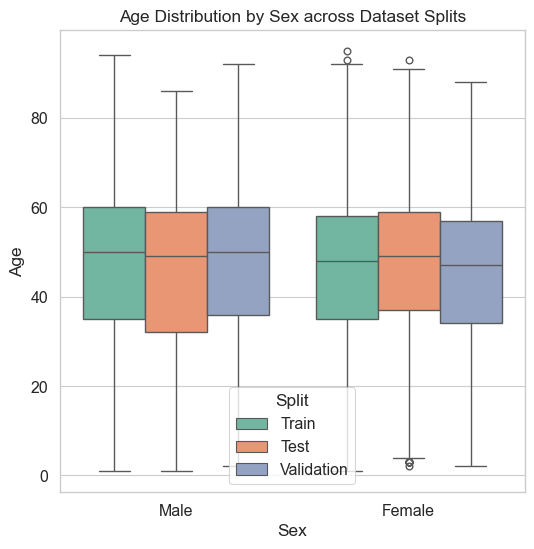

In [67]:
plt.figure(figsize=(6, 6))
ax = sns.boxplot(data=filter_df, x='Sex', y='Age', hue='Split', palette='Set2')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Train', 'Test', 'Validation'], title='Split', loc='lower center')

plt.title('Age Distribution by Sex across Dataset Splits')
plt.savefig('age_sex_boxplot.png')

## Sex Results

In [101]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path


models = {
    'eva_x_ti': 'EVA-X Tiny',
    'resnet': 'Resnet 50 CNN',
    'eva_x_base_linear': 'EVA-X Base (Log. Reg.)',
    'eva_x_sm_linear': 'EVA-X Small (Log. Reg.)',
    'eva_x_ti_linear': 'EVA-X Tiny (Log. Reg.)',
    'eva_x_ti_mlp': 'EVA-X Tiny (MLP)',
    'resnet50_no_sigmoid': 'Resnet 50 CNN'
}
AGE_STD_DEV = 16.60267981756069

def load_from_logs(path, is_age_regression=False):
    global models
    global AGE_STD_DEV

    # --------- DIRECTORY CONTAINING LOG FILES ----------
    log_dir = Path(path)   # change to your directory
    # ----------------------------------------------------

    def load_log(path):
        print(f"Loading {path}")
        records = []
        with open(path, "r") as f:
            for line in f:
                line = line.strip()
                if line:
                    records.append(json.loads(line))
                    
        df = pd.DataFrame(records)
        
        # Expand any list columns
        for col in df.columns:
            first_valid = df[col].dropna().iloc[0] if not df[col].dropna().empty else None

            if isinstance(first_valid, list):
                # Expand the list into new columns named 'col_0', 'col_1', etc.
                expanded_cols = pd.DataFrame(df[col].tolist(), index=df.index).add_prefix(f'{col}_')
                # Join back to main DF and drop the original list column
                df = pd.concat([df, expanded_cols], axis=1).drop(columns=[col])
                
        df = df.drop_duplicates()
        df = df.sort_values("epoch")
        return df


    # --------- Automatically collect all .txt files ----------
    log_files = sorted(log_dir.glob("*.txt"))

    if not log_files:
        raise ValueError(f"No .txt files found in {log_dir}")

    # --------- Combine all logs ----------
    all_dfs = []
    for path in log_files:
        df = load_log(path)
        df["Model"] = models[path.stem] if path.stem in models else path.stem   # filename (without .txt) as run label
        all_dfs.append(df)

    df_all = pd.concat(all_dfs, ignore_index=True)
    if is_age_regression:
        df_all['test_mae'] = df_all['test_mae'] * AGE_STD_DEV
        df_all['test_rmse'] = df_all['test_rmse'] * AGE_STD_DEV
    return df_all

In [117]:
df_all = load_from_logs('logs/sex')
df_all

Loading logs/sex/eva_x_ti.txt
Loading logs/sex/resnet.txt


,train_lr,train_loss,test_loss,test_auc_avg,epoch,n_parameters,test_auc_each_class_0,test_auc_each_class_1,Model
0,0.000099,0.634083,0.277415,0.967436,0,5525570,0.967433,0.967438,EVA-X Tiny
1,0.001000,0.244799,0.098127,0.993831,5,5525570,0.993827,0.993835,EVA-X Tiny
2,0.001000,0.201618,0.084899,0.995331,10,5525570,0.995324,0.995338,EVA-X Tiny
3,0.001000,0.183266,0.079156,0.996026,15,5525570,0.996007,0.996044,EVA-X Tiny
4,0.001000,0.170031,0.106087,0.995490,20,5525570,0.995474,0.995506,EVA-X Tiny
5,0.000100,0.353891,0.147262,0.986487,0,23512130,0.986527,0.986447,Resnet 50 CNN
6,0.001000,0.226655,0.159978,0.984926,5,23512130,0.984931,0.984922,Resnet 50 CNN
7,0.001000,0.196043,0.170808,0.988766,10,23512130,0.988765,0.988768,Resnet 50 CNN
8,0.001000,0.180186,0.112540,0.992283,15,23512130,0.992286,0.992281,Resnet 50 CNN
9,0.001000,0.172997,0.148543,0.990229,20,23512130,0.990243,0.990215,Resnet 50 CNN


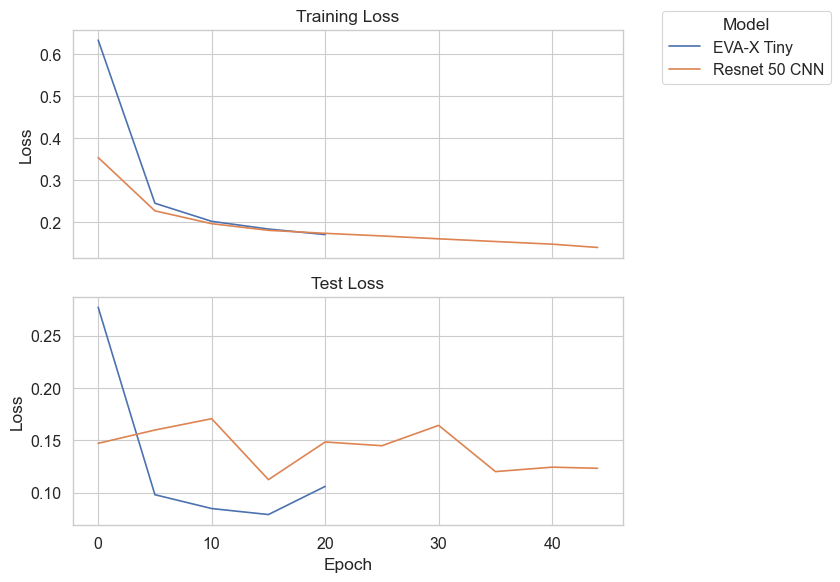

In [106]:
# --------- Academic styling ----------
sns.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.3
)

# --------- Create subplots ----------
fig, axes = plt.subplots(
    2, 1,
    figsize=(6.5, 6),
    sharex=True
)

# --------- Train subplot ----------
sns.lineplot(
    data=df_all,
    x="epoch",
    y="train_loss",
    hue="Model",
    ax=axes[0],
    legend=True
)
axes[0].set_title("Training Loss")
axes[0].set_ylabel("Loss")
axes[0].set_xlabel("")

# --------- Test subplot ----------
sns.lineplot(
    data=df_all,
    x="epoch",
    y="test_loss",
    hue="Model",
    ax=axes[1],
    legend=False
)
axes[1].set_title("Test Loss")
axes[1].set_ylabel("Loss")
axes[1].set_xlabel("Epoch")

# --------- Single shared legend ----------
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Model",
    bbox_to_anchor=(1.02, 0.98),
    loc="upper left"
)

# Remove duplicate legend in first axis
axes[0].legend_.remove()

plt.tight_layout()
plt.savefig("sex_loss.pdf", dpi=300, bbox_inches="tight")
plt.savefig("sex_loss.png", dpi=300, bbox_inches="tight")
plt.show()

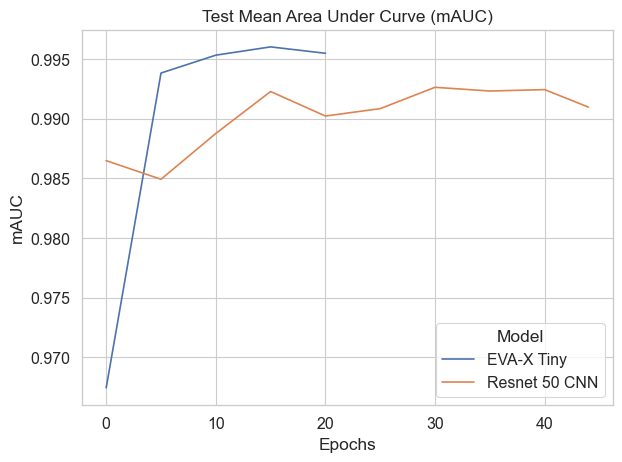

In [154]:
# --------- Academic styling ----------
sns.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.3
)


# MAE
sns.lineplot(
    data=df_all,
    x="epoch",
    y="test_auc_avg",
    hue="Model",
    legend=True
)
plt.title("Test Mean Area Under Curve (mAUC)")
plt.ylabel("mAUC")
plt.xlabel("Epochs")

plt.tight_layout()
plt.savefig("auc.pdf", dpi=300, bbox_inches="tight")
plt.savefig("auc.png", dpi=300, bbox_inches="tight")
plt.show()

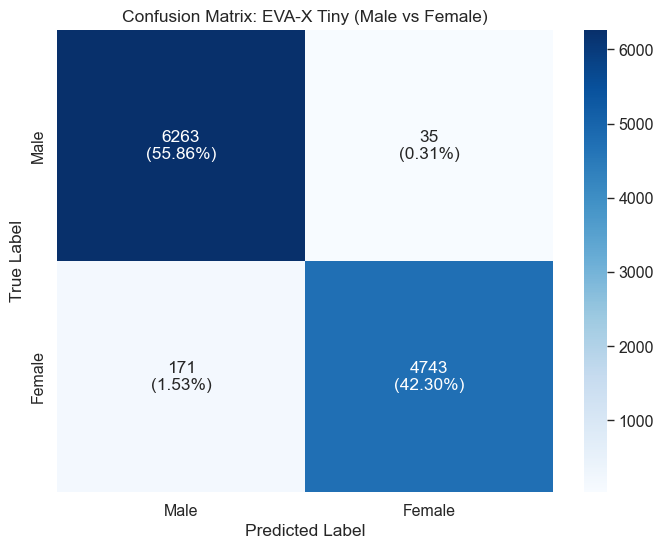

In [155]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

y_true_raw = np.load('logs/sex/y_gt_eva.npy')    # Shape is (N, 2)
y_probs_raw = np.load('logs/sex/y_pred_eva.npy') # Shape is (N, 2)

# 1. Process data (0=Male, 1=Female)
y_true = np.argmax(y_true_raw, axis=1)
y_pred = np.argmax(y_probs_raw, axis=1)
cm = confusion_matrix(y_true, y_pred)

# 2. Create labels with Counts and Percentages
# We flatten the matrix and calculate percentages of the whole
group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n({v2})" for v1, v2 in zip(group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2,2)

# 3. Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', 
            xticklabels=['Male', 'Female'], 
            yticklabels=['Male', 'Female'])

plt.title('Confusion Matrix: EVA-X Tiny (Male vs Female)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [156]:
# Generate the report
report = classification_report(y_true, y_pred, target_names=['Male', 'Female'])
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

        Male       0.97      0.99      0.98      6298
      Female       0.99      0.97      0.98      4914

    accuracy                           0.98     11212
   macro avg       0.98      0.98      0.98     11212
weighted avg       0.98      0.98      0.98     11212



In [158]:
def calculate_ece(y_true_one_hot, y_probs_raw, n_bins=10):
    # 1. Convert to 1D: Get the actual label and the probability of the predicted class
    y_true = np.argmax(y_true_one_hot, axis=1)
    y_pred = np.argmax(y_probs_raw, axis=1)
    confidences = np.max(y_probs_raw, axis=1)
    
    # 2. Setup bins
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0
    n = len(y_true)
    
    for i in range(n_bins):
        # Find indices of predictions falling into this bin (Bm)
        bin_lower, bin_upper = bin_boundaries[i], bin_boundaries[i+1]
        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        prop_in_bin = np.mean(in_bin) # |Bm| / N
        
        if prop_in_bin > 0:
            # Accuracy in bin: average of correct predictions
            accuracy_in_bin = np.mean(y_true[in_bin] == y_pred[in_bin])
            # Confidence in bin: average of predicted probabilities
            avg_confidence_in_bin = np.mean(confidences[in_bin])
            
            # ECE summation logic
            ece += prop_in_bin * np.abs(accuracy_in_bin - avg_confidence_in_bin)
            
    return ece

ece_value = calculate_ece(y_true_raw, y_probs_raw)
print(f"EVA-X-Ti Expected Calibration Error (ECE): {ece_value:.4f}")

EVA-X-Ti Expected Calibration Error (ECE): 0.0060


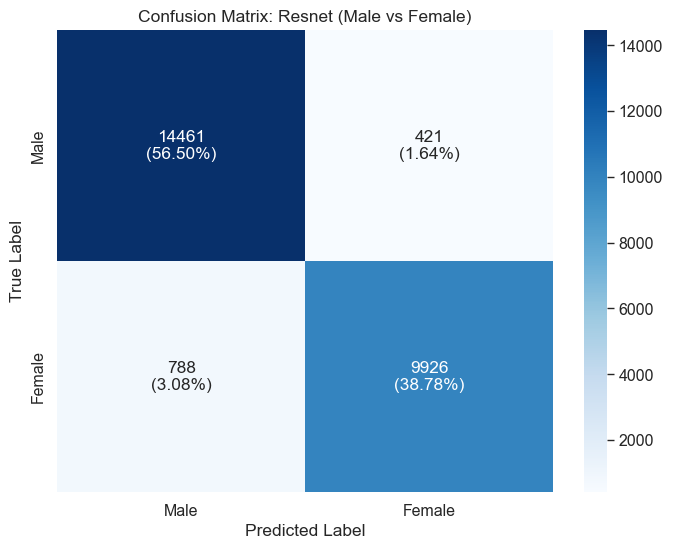

In [159]:
# TODO: Run eval on CNN to get representative y_gt and y_pred!
# This is currently running on the test set, not the eval set
# so cannot be compared to EVA-X
y_true_raw = np.load('logs/sex/y_gt_resnet.npy')    # Shape is (N, 2)
y_probs_raw = np.load('logs/sex/y_pred_resnet.npy') # Shape is (N, 2)

# 1. Process data (0=Male, 1=Female)
y_true = np.argmax(y_true_raw, axis=1)
y_pred = np.argmax(y_probs_raw, axis=1)
cm = confusion_matrix(y_true, y_pred)

# 2. Create labels with Counts and Percentages
# We flatten the matrix and calculate percentages of the whole
group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n({v2})" for v1, v2 in zip(group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2,2)

# 3. Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', 
            xticklabels=['Male', 'Female'], 
            yticklabels=['Male', 'Female'])

plt.title('Confusion Matrix: Resnet (Male vs Female)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [160]:
# Generate the report
report = classification_report(y_true, y_pred, target_names=['Male', 'Female'])
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

        Male       0.95      0.97      0.96     14882
      Female       0.96      0.93      0.94     10714

    accuracy                           0.95     25596
   macro avg       0.95      0.95      0.95     25596
weighted avg       0.95      0.95      0.95     25596



In [161]:
ece_value = calculate_ece(y_true_raw, y_probs_raw)
print(f"Resnet Expected Calibration Error (ECE): {ece_value:.4f}")

Resnet Expected Calibration Error (ECE): 0.0133


In [153]:
def get_model_summary(group):
    # Sort by epoch to ensure we get the true final row
    group = group.sort_values('epoch')
    
    final_row = group.iloc[-1]
    best_row = group.loc[group['test_auc_avg'].idxmin()]
    
    return pd.Series({
        'Final_AUC_Avg': final_row['test_auc_avg'],
        'Best_AUC_Avg': best_row['test_auc_avg'],
        'Best_Epoch_AUC': best_row['epoch']
    })

# Apply the function to each model group
summary_df = df_all.groupby('Model').apply(get_model_summary).sort_values('Final_AUC_Avg', ascending=False).reset_index()

summary_df

,Model,Final_AUC_Avg,Best_AUC_Avg,Best_Epoch_AUC
0,EVA-X Tiny,0.995490,0.967436,0.0
1,Resnet 50 CNN,0.990977,0.984926,5.0


## Age Results

In [111]:
df_all = load_from_logs('logs/age')
df_all.head(5)

Loading logs/age/eva_x_base_linear.txt
Loading logs/age/eva_x_sm_linear.txt
Loading logs/age/eva_x_ti_linear.txt
Loading logs/age/eva_x_ti_mlp.txt
Loading logs/age/resnet50_no_sigmoid.txt


,train_lr,train_loss,test_loss,test_mae,test_mse,test_rmse,epoch,n_parameters,Model
0,0.000100,0.609895,0.251118,0.347558,0.251137,0.501136,0,85851649,EVA-X Base (Log. Reg.)
1,0.000999,0.253976,0.197110,0.297818,0.197128,0.443990,5,85851649,EVA-X Base (Log. Reg.)
2,0.000954,0.219262,0.181668,0.280289,0.181687,0.426248,10,85851649,EVA-X Base (Log. Reg.)
3,0.000840,0.194059,0.216811,0.318220,0.216829,0.465649,15,85851649,EVA-X Base (Log. Reg.)
4,0.000673,0.183513,0.184199,0.280529,0.184217,0.429205,20,85851649,EVA-X Base (Log. Reg.)


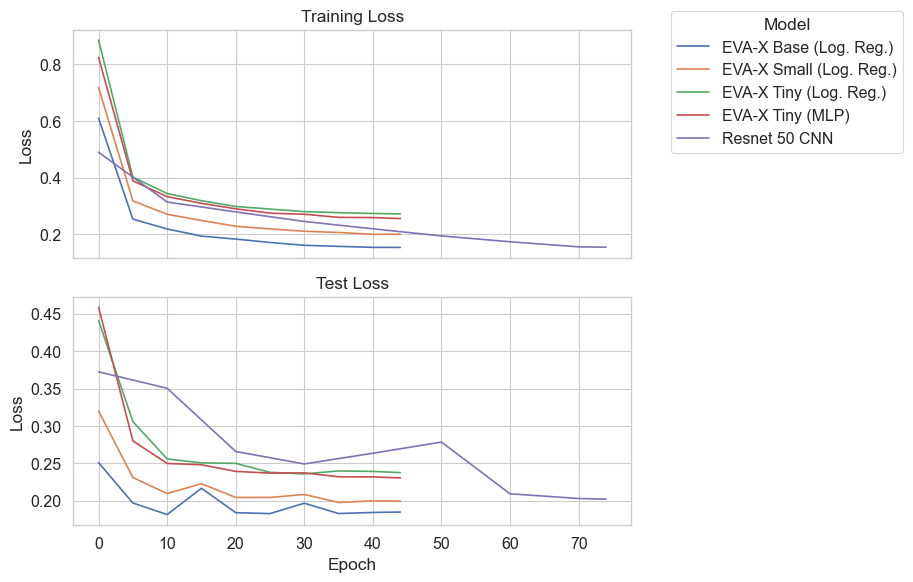

In [112]:
# --------- Academic styling ----------
sns.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.3
)

# --------- Create subplots ----------
fig, axes = plt.subplots(
    2, 1,
    figsize=(6.5, 6),
    sharex=True
)

# --------- Train subplot ----------
sns.lineplot(
    data=df_all,
    x="epoch",
    y="train_loss",
    hue="Model",
    ax=axes[0],
    legend=True
)
axes[0].set_title("Training Loss")
axes[0].set_ylabel("Loss")
axes[0].set_xlabel("")
#axes[0].set_yscale('log')

# --------- Test subplot ----------
sns.lineplot(
    data=df_all,
    x="epoch",
    y="test_loss",
    hue="Model",
    ax=axes[1],
    legend=False
)
axes[1].set_title("Test Loss")
axes[1].set_ylabel("Loss")
axes[1].set_xlabel("Epoch")
#axes[1].set_yscale('log')

# --------- Single shared legend ----------
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Model",
    bbox_to_anchor=(1.02, 0.98),
    loc="upper left"
)

# Remove duplicate legend in first axis
axes[0].legend_.remove()

plt.tight_layout()
plt.savefig("age_loss.pdf", dpi=300, bbox_inches="tight")
plt.savefig("age_loss.png", dpi=300, bbox_inches="tight")
plt.show()

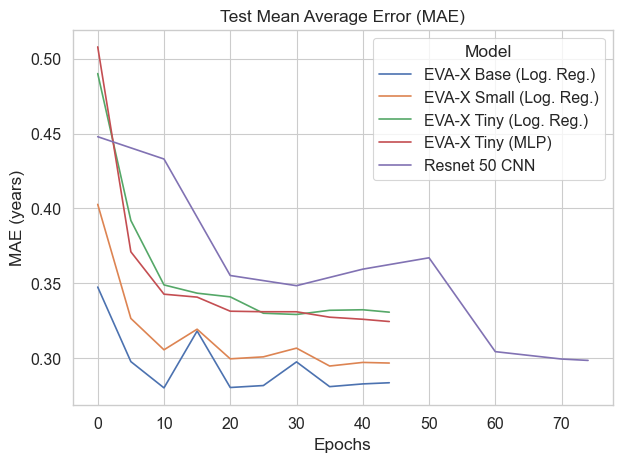

In [113]:
# --------- Academic styling ----------
sns.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.3
)


# MAE
sns.lineplot(
    data=df_all,
    x="epoch",
    y="test_mae",
    hue="Model",
    legend=True
)
plt.title("Test Mean Average Error (MAE)")
plt.ylabel("MAE (years)")
plt.xlabel("Epochs")

plt.tight_layout()
plt.savefig("mae.pdf", dpi=300, bbox_inches="tight")
plt.savefig("mae.png", dpi=300, bbox_inches="tight")
plt.show()

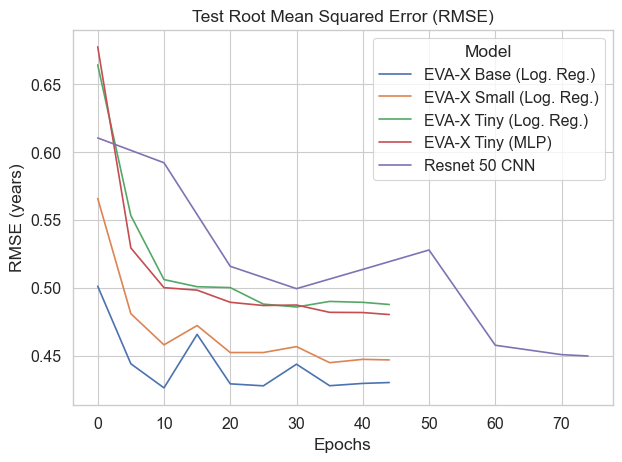

In [114]:
# --------- Academic styling ----------
sns.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.3
)


# MAE
sns.lineplot(
    data=df_all,
    x="epoch",
    y="test_rmse",
    hue="Model",
    legend=True
)
plt.title("Test Root Mean Squared Error (RMSE)")
plt.ylabel("RMSE (years)")
plt.xlabel("Epochs")

plt.tight_layout()
plt.savefig("rmse.pdf", dpi=300, bbox_inches="tight")
plt.savefig("rmse.png", dpi=300, bbox_inches="tight")
plt.show()

In [115]:
def get_model_summary(group):
    # Sort by epoch to ensure we get the true final row
    group = group.sort_values('epoch')
    
    final_row = group.iloc[-1]
    best_row = group.loc[group['test_mae'].idxmin()]
    
    return pd.Series({
        'Final_MAE': final_row['test_mae'],
        'Best_MAE': best_row['test_mae'],
        'Final_RMSE': final_row['test_rmse'],
        'Best_RMSE': best_row['test_rmse'],
        'Best_Epoch_MAE': best_row['epoch']
    })

# Apply the function to each model group
summary_df = df_all.groupby('Model').apply(get_model_summary).sort_values('Final_MAE').reset_index()

summary_df

,Model,Final_MAE,Best_MAE,Final_RMSE,Best_RMSE,Best_Epoch_MAE
0,EVA-X Base (Log. Reg.),0.283701,0.280289,0.430177,0.426248,10.0
1,EVA-X Small (Log. Reg.),0.296858,0.294866,0.446839,0.444810,35.0
2,Resnet 50 CNN,0.298617,0.298617,0.449732,0.449732,74.0
3,EVA-X Tiny (MLP),0.324566,0.324566,0.480265,0.480265,44.0
4,EVA-X Tiny (Log. Reg.),0.330802,0.329280,0.487676,0.485821,30.0
